In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import argparse
import pandas as pd
import numpy as np
import tfsplt_future_past_utils as pu

In [2]:
# define parameters
class Args(argparse.Namespace):

    rois = ["IFG","MTG", "STG","preCG","postCG", "rostralmiddlefrontal",
        "superiorfrontal", "supramarginal", "ITG", "TP", "fusiform", "All"]
    # rois = ["IFG","STG","preCG","postCG","TP","dSM","mSM","vSM", "All"]    
    
    # NOTE: lines must match the label3 values in the data (includes _banded_ prefix)
    lines = ["_banded_joint", "_banded_word", "_banded_sentence", "_banded_sentence2"] # line id
    # colors = ["green", "grey", "orange", "red", "black", "purple"]
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    legends = ["joint", "word", "future", "past"]

    lags = {
            "lags_all": np.arange(-2000, 2001, 50),
            "lags_plt": np.arange(-2000, 2001, 50), # selected subset
            "lag_ticks": np.arange(-2000, 2001, 500), # this and next one need to have same number of elements
            "lag_tick_labels": np.arange(-2, 2.001, 0.5), # this and previous one need to have same number of elements
        }
    res_dir = '/scratch/gpfs/gidon/247-plotting/results/figures'

In [5]:
args = Args()
all_elecs = pd.read_csv("/scratch/gpfs/HASSON/kw1166/247/247-plotting/data/plotting/paper-sts/base_df.csv")
thresh_single = None # DON'T use thresh here - utility function has bug with '_banded_joint'
res_d = "/scratch/gpfs/HASSON/gidon/247-encoding-dev/results/tfs"

shared_ind_l, shared_ind_m, shared_ind_s = pu.get_shared_indices(np.arange(-120000, 120001, 50), np.arange(-2000, 2001, 25), lags_med=np.arange(-60000,60001,50))

# load results (all pca 300)
# no reph
# ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_prod
no_reph_c = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_untrained_original_sentence_comp.csv", thresh_single)
no_reph_p = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_untrained_original_sentence_prod.csv", thresh_single)

print(f"Loaded original sentences: {len(no_reph_c)} comprehension, {len(no_reph_p)} production electrodes")

# Select shared lag columns
no_reph_c = pu.select_shared_and_last_columns(no_reph_c, shared_ind_m)
no_reph_p = pu.select_shared_and_last_columns(no_reph_p, shared_ind_m)

reph_c = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph_rand-m-diff-w-2_pca300_drop-short_mistral_untrained_rephrased_sentence_comp.csv", thresh_single)
reph_p = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph_rand-m-diff-w-2_pca300_drop-short_mistral_untrained_rephrased_sentence_prod.csv", thresh_single)

print(f"Loaded rephrased sentences: {len(reph_c)} comprehension, {len(reph_p)} production electrodes")

reph_c = pu.select_shared_and_last_columns(reph_c, shared_ind_m)
reph_p = pu.select_shared_and_last_columns(reph_p, shared_ind_m)

# Compile dataframes and titles
df_list_c = [no_reph_c, reph_c]
df_list_p = [no_reph_p, reph_p]
titles = ["no rephrase", "rephrase"]

print(f"\nProcessing {len(df_list_c)} conditions with ROI filtering...")

# NOTE: Must pass results with correct label3 values (includes _banded_ prefix)
# NOTE: OR_thresh not used because threshold_results_by_joint() has bug (expects 'joint' not '_banded_joint')
shared_electrodes_c, filtered_dfs_c, roi_results_c = pu.process_shared_electrodes_roi(
    df_list_c,
    args.rois,
    results=['_banded_joint', '_banded_word', '_banded_sentence', '_banded_sentence2'],
    OR_thresh=None
)
shared_electrodes_p, filtered_dfs_p, roi_results_p = pu.process_shared_electrodes_roi(
    df_list_p,
    args.rois,
    results=['_banded_joint', '_banded_word', '_banded_sentence', '_banded_sentence2'],
    OR_thresh=None
)

print(f"Found {len(shared_electrodes_c)} comprehension and {len(shared_electrodes_p)} production shared electrodes across conditions")


Loaded original sentences: 2640 comprehension, 2524 production electrodes
Loaded rephrased sentences: 2636 comprehension, 2608 production electrodes

Processing 2 conditions with ROI filtering...
Found 640 comprehension and 604 production shared electrodes across conditions
Loaded rephrased sentences: 2636 comprehension, 2608 production electrodes

Processing 2 conditions with ROI filtering...
Found 640 comprehension and 604 production shared electrodes across conditions


In [6]:
# Process and plot for comprehension (c) DataFrames
rois_to_plot_c = []
for roi in args.rois:
    key = (0, 'joint', roi)
    df = roi_results_c.get(key)
    if df is not None and df.shape[0] > 2:
        rois_to_plot_c.append(roi)

# TODO FIX all of this 
for roi in rois_to_plot_c:
    # Count electrodes in all comprehension datasets for this ROI
    # TODO fix this
    n_elecs_c = next(
    (len(df) for key, df in roi_results_c.items() 
     if key[2] == roi and isinstance(df, pd.DataFrame) and not df.empty), 
    0
    )
    
    if n_elecs_c < 3:
        continue
    # TODO - is it supposed to get dfs or dict? look at orig func in podcast
    pu.plot_single_roi_side_by_side(
        args, 
        roi_results_c, 
        roi, 
        mode="comp", 
        ymax=0.18, 
        save=False, 
        titles=titles
    )

In [7]:
# Process and plot for comprehension (c) DataFrames
rois_to_plot_p = []
for roi in args.rois:
    key = (0, 'joint', roi)
    df = roi_results_p.get(key)
    if df is not None and df.shape[0] > 2:
        rois_to_plot_p.append(roi)

# TODO FIX all of this 
for roi in rois_to_plot_p:
    # Count electrodes in all comprehension datasets for this ROI
    # TODO fix this
    n_elecs_p = next(
    (len(df) for key, df in roi_results_p.items() 
     if key[2] == roi and isinstance(df, pd.DataFrame) and not df.empty), 
    0
    )
    
    if n_elecs_p < 3:
        continue
    # TODO - is it supposed to get dfs or dict? look at orig func in podcast
    pu.plot_single_roi_side_by_side(
        args, 
        roi_results_p, 
        roi, 
        mode="prod", 
        ymax=0.18, 
        save=False, 
        titles=titles
    )

In [8]:
def plot_single_line_across_datasets(args, sig_results_dict, roi, line, mode="comp", ymax=0.18, save=False, titles=None):
    """
    Plot a single line (e.g., 'joint', 'word', etc.) across multiple datasets side-by-side.
    Each dataset is shown in a different shade of the same color.
    
    Parameters:
    -----------
    args : Args object
        Contains configuration parameters
    sig_results_dict : dict
        Dictionary keyed by (i, line, roi) containing DataFrames
    roi : str
        ROI name to plot
    line : str
        Specific line to plot (e.g., 'joint', 'word', 'sentence', 'sentence2')
    mode : str
        "comp" or "prod"
    ymax : float
        Maximum y-axis value
    save : bool
        Whether to save the figure
    titles : list of str, optional
        Custom titles for each dataset. If None, uses generic titles.
    """
    # Determine number of datasets from keys
    dataset_indices = sorted(set(key[0] for key in sig_results_dict.keys()))
    n_datasets = len(dataset_indices)
    
    if titles is None:
        titles = [f"Dataset {i+1}" for i in range(n_datasets)]
    
    # Create single axis
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Get base color for this line
    line_idx = args.lines.index(line) if line in args.lines else 0
    base_color = args.colors[line_idx]
    
    # Convert to RGB and create shades
    from matplotlib.colors import to_rgb
    rgb = to_rgb(base_color)
    
    # Plot each dataset with different opacity/shade (REVERSED)
    for i, dataset_idx in enumerate(dataset_indices):
        # Create progressively darker/lighter shades (REVERSED ORDER)
        alpha = 1.0 - (0.6 * i / max(1, n_datasets - 1))  # Range from 1.0 to 0.4
        
        key = (dataset_idx, line, roi)
        
        if key not in sig_results_dict or sig_results_dict[key].empty:
            continue
        
        df_line = sig_results_dict[key]
        
        # Count electrodes
        n_elecs = len(df_line)
        label = f"{titles[i]} (n={n_elecs})"
        
        # Plot line with varying alpha
        lags_selected = [lag_idx for lag_idx, lag in enumerate(args.lags["lags_all"]) 
                        if lag in args.lags["lags_plt"]]
        vals = df_line.iloc[:, lags_selected].mean(axis=0)
        errs = df_line.iloc[:, lags_selected].sem(axis=0)
        
        ax.plot(
            args.lags["lags_plt"],
            vals,
            color=base_color,
            alpha=alpha,
            label=label,
            lw=2.5,
        )
        ax.fill_between(
            args.lags["lags_plt"],
            vals - errs,
            vals + errs,
            alpha=alpha * 0.3,
            color=base_color,
        )
    
    # Ax cosmetics
    if ymax is not None:
        ax.set_ylim(top=ymax, bottom=-0.025)
    ymin, ymax_val = ax.get_ylim()
    
    # Shade time window
    if mode == "comp":
        rect1 = patches.Rectangle((50, ymin), 450, ymax_val - ymin, 
                                  color="yellowgreen", alpha=0.3, label="_nolegend_")
    elif mode == "prod":
        rect1 = patches.Rectangle((-500, ymin), 450, ymax_val - ymin, 
                                  color="indianred", alpha=0.3, label="_nolegend_")
    ax.add_patch(rect1)
    
    ax.axhline(0, ls="dashed", alpha=0.3, c="k")
    ax.axvline(0, ls="dashed", alpha=0.3, c="k")
    ax.set_xticks(args.lags["lag_ticks"])
    ax.set_xticklabels(args.lags["lag_tick_labels"])
    ax.tick_params(axis='both', which='both', labelsize=10)
    ax.legend(loc="best", frameon=False, fontsize=10)
    
    mode_full = "Comprehension" if mode == "comp" else "Production"
    ax.set_title(f"{mode_full} - {roi} - {args.legends[line_idx]}", fontsize=12)
    
    plt.tight_layout()
    if save:
        plt.savefig(f"{args.res_dir}/{roi}_{line}_overlay_{mode}.jpeg")
        plt.close(fig)
    else:
        plt.show()

def plot_all_lines_across_datasets(args, sig_results_dict, roi, mode="comp", ymax=0.18, save=False, titles=None):
    """
    Plot all lines (joint, word, sentence, sentence2) across multiple datasets in a row of subplots.
    Each subplot shows one line type with different datasets in different shades.
    
    Parameters:
    -----------
    args : Args object
        Contains configuration parameters
    sig_results_dict : dict
        Dictionary keyed by (i, line, roi) containing DataFrames
    roi : str
        ROI name to plot
    mode : str
        "comp" or "prod"
    ymax : float
        Maximum y-axis value
    save : bool
        Whether to save the figure
    titles : list of str, optional
        Custom titles for each dataset. If None, uses generic titles.
    """
    # Determine number of datasets from keys
    dataset_indices = sorted(set(key[0] for key in sig_results_dict.keys()))
    n_datasets = len(dataset_indices)
    
    if titles is None:
        titles = [f"Dataset {i+1}" for i in range(n_datasets)]
    
    # Create figure with 4 subplots in a row
    n_lines = len(args.lines)
    fig, axes = plt.subplots(1, n_lines, figsize=(20, 5))
    
    # Plot each line type in its own subplot
    for line_idx, line in enumerate(args.lines):
        ax = axes[line_idx]
        
        # Get base color for this line
        base_color = args.colors[line_idx]
        
        # Plot each dataset with different opacity/shade (REVERSED)
        for i, dataset_idx in enumerate(dataset_indices):
            # Create progressively darker/lighter shades (REVERSED ORDER)
            alpha = 1.0 - (0.6 * i / max(1, n_datasets - 1))  # Range from 1.0 to 0.4
            
            key = (dataset_idx, line, roi)
            
            if key not in sig_results_dict or sig_results_dict[key].empty:
                continue
            
            df_line = sig_results_dict[key]
            
            # Count electrodes
            n_elecs = len(df_line)
            label = f"{titles[i]} (n={n_elecs})"
            
            # Plot line with varying alpha
            lags_selected = [lag_idx for lag_idx, lag in enumerate(args.lags["lags_all"]) 
                            if lag in args.lags["lags_plt"]]
            vals = df_line.iloc[:, lags_selected].mean(axis=0)
            errs = df_line.iloc[:, lags_selected].sem(axis=0)
            
            ax.plot(
                args.lags["lags_plt"],
                vals,
                color=base_color,
                alpha=alpha,
                label=label,
                lw=2.5,
            )
            ax.fill_between(
                args.lags["lags_plt"],
                vals - errs,
                vals + errs,
                alpha=alpha * 0.3,
                color=base_color,
            )
        
        # Ax cosmetics
        if ymax is not None:
            ax.set_ylim(top=ymax, bottom=-0.025)
        ymin, ymax_val = ax.get_ylim()
        
        # Shade time window
        if mode == "comp":
            rect1 = patches.Rectangle((50, ymin), 450, ymax_val - ymin, 
                                      color="yellowgreen", alpha=0.3, label="_nolegend_")
        elif mode == "prod":
            rect1 = patches.Rectangle((-500, ymin), 450, ymax_val - ymin, 
                                      color="indianred", alpha=0.3, label="_nolegend_")
        ax.add_patch(rect1)
        
        ax.axhline(0, ls="dashed", alpha=0.3, c="k")
        ax.axvline(0, ls="dashed", alpha=0.3, c="k")
        ax.set_xticks(args.lags["lag_ticks"])
        ax.set_xticklabels(args.lags["lag_tick_labels"])
        ax.tick_params(axis='both', which='both', labelsize=10)
        
        ax.legend(loc="best", frameon=False, fontsize=9)
        
        mode_full = "Comprehension" if mode == "comp" else "Production"
        ax.set_title(f"{args.legends[line_idx]}", fontsize=12)
        
    
    # Add overall title
    mode_full = "Comprehension" if mode == "comp" else "Production"
    fig.suptitle(f"{mode_full} - {roi}", fontsize=14, y=1.02)
    
    plt.tight_layout()
    if save:
        plt.savefig(f"{args.res_dir}/{roi}_all_lines_overlay_{mode}.jpeg", bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()

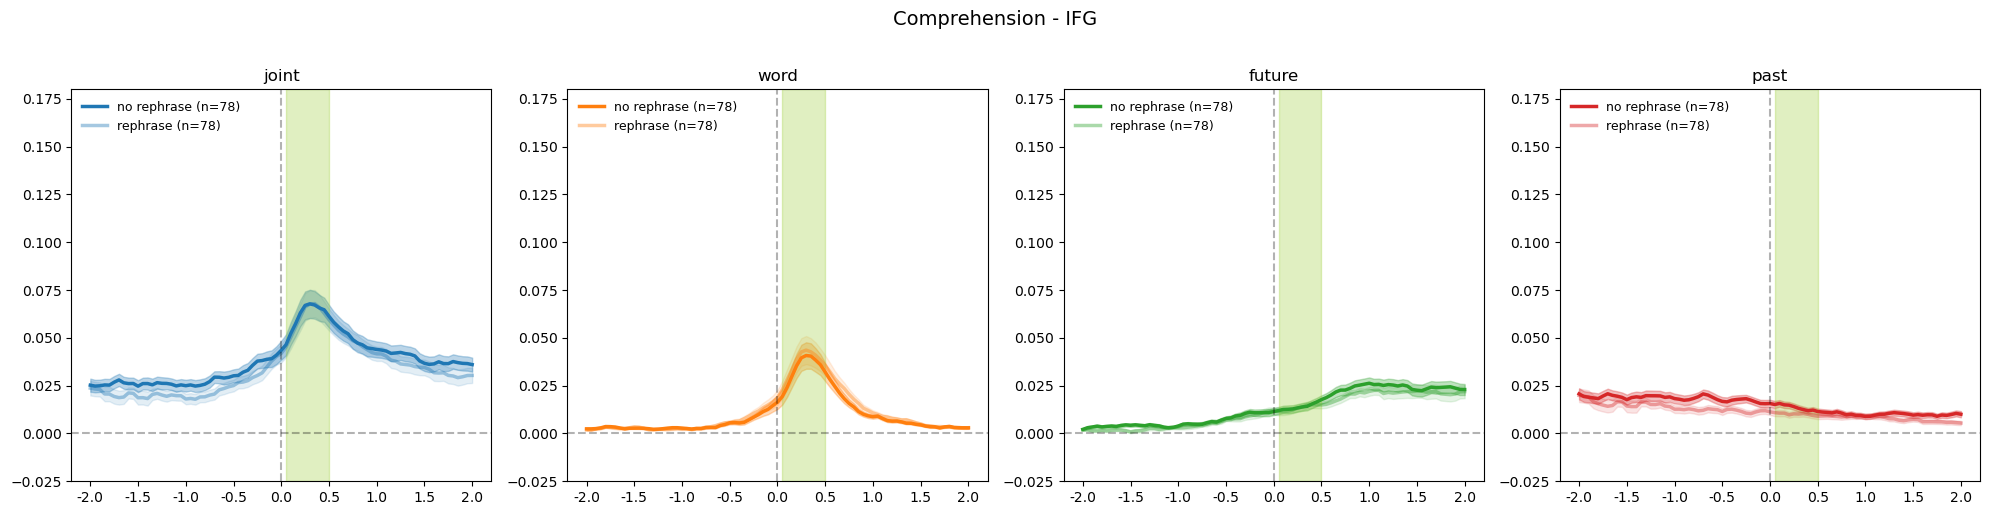

In [15]:
# plot_single_line_across_datasets(
#     args, 
#     roi_results_c, 
#     roi="IFG",
#     line="word",  # or "word", "sentence", "sentence2"
#     mode="comp", 
#     ymax=0.18, 
#     save=False, 
#     titles=["no rephrase", "translate", "rephrase_opposite similar wording"]
# )
plot_all_lines_across_datasets(
    args, 
    roi_results_c, 
    roi="IFG",
    mode="comp", 
    ymax=0.18, 
    save=False, 
    titles=titles
)

In [17]:
rois_to_plot_c = []
for roi in args.rois:
    key = (0, 'joint', roi)
    df = roi_results_c.get(key)
    if df is not None and df.shape[0] > 2:
        rois_to_plot_c.append(roi)

for roi in rois_to_plot_c:
    # Count electrodes in all comprehension datasets for this ROI
    n_elecs_c = next(
        (len(df) for key, df in roi_results_c.items() 
         if key[2] == roi and isinstance(df, pd.DataFrame) and not df.empty), 
        0
    )
    
    if n_elecs_c < 3:
        continue
    
    plot_all_lines_across_datasets(
        args, 
        roi_results_c, 
        roi, 
        mode="comp", 
        ymax=0.18, 
        save=False, 
        titles=titles
    )

In [22]:
rois_to_plot_p = []
for roi in args.rois:
    key = (0, 'joint', roi)
    df = roi_results_p.get(key)
    if df is not None and df.shape[0] > 2:
        rois_to_plot_p.append(roi)

for roi in rois_to_plot_p:
    # Count electrodes in all production datasets for this ROI
    n_elecs_p = next(
        (len(df) for key, df in roi_results_p.items() 
         if key[2] == roi and isinstance(df, pd.DataFrame) and not df.empty), 
        0
    )
    
    if n_elecs_p < 3:
        continue
    
    plot_all_lines_across_datasets(
        args, 
        roi_results_p, 
        roi, 
        mode="prod", 
        ymax=0.18, 
        save=False, 
        titles=titles
    )

In [54]:
# get max diffreence between 2 datasets per electrode no_reph_c, reph_rand_m_diff_w_c

# df_list_c = [no_reph_c, reph_tra_c, reph_opp_m_sim_w_c, reph_opp_m_diff_c, reph_rand_m_diff_w_c, reph_shuf_c]
# df_list_p = [no_reph_p, reph_tra_p, reph_opp_m_sim_w_p, reph_opp_m_diff_p, reph_rand_m_diff_w_p, reph_shuf_p]
# titles = ["no rephrase", "translate", "rephrase_opposite similar wording", "rephrase_opposite different wording", "rephrase_random", "shuffled_sentences"]

shared_ind_l, shared_ind_s = pu.get_shared_indices(np.arange(-120000, 120001, 50), np.arange(-60000,60001,50))
# load results (all pca 300)
# no reph
# no_reph_c = pu.load_res_add_roi_threshold(f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-reph-translate-control_120s_drop-short_mistral_comp.csv", 0.1)
# no_reph_p = pu.load_res_add_roi_threshold(f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-reph-translate-control_120s_drop-short_mistral_prod.csv", 0.1)
no_reph_c = pu.load_res_add_roi_threshold(f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_comp.csv", 0.1)
no_reph_p = pu.load_res_add_roi_threshold(f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_prod.csv", 0.1)
no_reph_c = pu.select_shared_and_last_columns(no_reph_c, shared_ind_s)
no_reph_p = pu.select_shared_and_last_columns(no_reph_p, shared_ind_s)





# reph rand
reph_rand_m_diff_w_c = pu.load_res_add_roi_threshold(f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag120k-50-all-static_future_past-reph-rand-m-diff-w-2_drop-short_mistral_comp.csv", 0.1)
reph_rand_m_diff_w_p = pu.load_res_add_roi_threshold(f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag120k-50-all-static_future_past-reph-rand-m-diff-w-2_drop-short_mistral_prod.csv", 0.1)
reph_rand_m_diff_w_c = pu.select_shared_and_last_columns(reph_rand_m_diff_w_c, shared_ind_l)
reph_rand_m_diff_w_p = pu.select_shared_and_last_columns(reph_rand_m_diff_w_p, shared_ind_l)


# rename all columns (until -5:) to np.arange(-60000,60001,50)


lag_cols = np.arange(-60000,60001,50)

for df in [no_reph_c, no_reph_p, reph_rand_m_diff_w_c, reph_rand_m_diff_w_p]:
    n_lag_cols = len(df.columns) - 5
    new_columns = list(lag_cols[:n_lag_cols]) + list(df.columns[-5:])
    df.columns = new_columns

# print(no_reph_c.columns)
# print(reph_rand_m_diff_w_c.columns)

# # loop over dfs and rename cols to np.arange(-120000, 120001, 50)
# for df in [no_reph_c, no_reph_p, reph_rand_m_diff_w_c, reph_rand_m_diff_w_p]:
#     df.columns = list(lag_cols) + list(df.columns[len(lag_cols):])

# Comp Calc max difference future time<0.5s pas > 0s
# Prod future <0 past > -0.5s

# calc diffs between no reph and reph random (same subject + electrode)
# label3 == sentence comprehension get 90th percentile biggest diff for columns <=500
# label3 == sentence2 comprehension get 90th percentile biggest diff for columns >=0
# label3 == sentence production get 90th percentile biggest diff for columns <=0
# label3 == sentence2 production get 90th percentile biggest diff for columns >=-500
# 
 


In [ ]:
lag_cols = np.arange(-60000,60001,50)


In [ ]:
# Calculate differences between no reph and reph random (same subject + electrode)
def calc_max_diff_percentile(df_control, df_reph, label3_val, time_window_cols, percentile=90):
    """
    Calculate the Nth percentile of maximum absolute differences within a time window.
    
    Parameters:
    -----------
    df_control : pd.DataFrame
        Control (no rephrase) dataframe
    df_reph : pd.DataFrame
        Rephrase dataframe
    label3_val : str
        'sentence' or 'sentence2'
    time_window_cols : list
        Column names (lags) to consider
    percentile : int
        Percentile to calculate (default 90)
    
    Returns:
    --------
    pd.DataFrame with electrode, subject, max_diff, and percentile info
    """
    results = []
    
    # Filter by label3
    df_control_filt = df_control[df_control['label3'] == label3_val].copy()
    df_reph_filt = df_reph[df_reph['label3'] == label3_val].copy()
    
    # Merge on subject and electrode to match
    merged = df_control_filt.merge(
        df_reph_filt,
        on=['subject', 'electrode'],
        suffixes=('_control', '_reph')
    )
    
    print(f"\nProcessing {label3_val}: {len(merged)} matched electrodes")
    
    for idx, row in merged.iterrows():
        # Get values in time window for both conditions
        control_vals = row[[f"{col}_control" for col in time_window_cols if f"{col}_control" in row.index]]
        reph_vals = row[[f"{col}_reph" for col in time_window_cols if f"{col}_reph" in row.index]]
        
        # Calculate absolute differences
        diffs = np.abs(control_vals.values - reph_vals.values)
        
        # Get max difference
        max_diff = np.max(diffs)
        max_diff_lag = time_window_cols[np.argmax(diffs)]
        
        results.append({
            'subject': row['subject'],
            'electrode': row['electrode'],
            'label3': label3_val,
            'max_diff': max_diff,
            'max_diff_lag': max_diff_lag,
            'roi': row.get('roi_control', row.get('roi_reph', 'unknown'))
        })
    
    results_df = pd.DataFrame(results)
    
    if len(results_df) > 0:
        percentile_val = np.percentile(results_df['max_diff'], percentile)
        print(f"{percentile}th percentile max diff: {percentile_val:.4f}")
        results_df[f'above_{percentile}th_percentile'] = results_df['max_diff'] >= percentile_val
    
    return results_df

# Define time windows for each condition
# Comprehension
time_window_future_comp = [col for col in lag_cols if col <= 500]  # <= 0.5s
time_window_past_comp = [col for col in lag_cols if col >= 0]      # >= 0s

# Production  
time_window_future_prod = [col for col in lag_cols if col <= 0]     # <= 0s
time_window_past_prod = [col for col in lag_cols if col >= -500]    # >= -0.5s

# Calculate for comprehension
diff_sent_comp = calc_max_diff_percentile(
    no_reph_c, reph_rand_m_diff_w_c, 
    'sentence', time_window_future_comp, percentile=90
)

diff_sent2_comp = calc_max_diff_percentile(
    no_reph_c, reph_rand_m_diff_w_c,
    'sentence2', time_window_past_comp, percentile=90
)

# Calculate for production
diff_sent_prod = calc_max_diff_percentile(
    no_reph_p, reph_rand_m_diff_w_p,
    'sentence', time_window_future_prod, percentile=90
)

diff_sent2_prod = calc_max_diff_percentile(
    no_reph_p, reph_rand_m_diff_w_p,
    'sentence2', time_window_past_prod, percentile=90
)


# Combine all results
all_diffs = pd.concat([
    diff_sent_comp.assign(mode='comp'),
    diff_sent2_comp.assign(mode='comp'),
    diff_sent_prod.assign(mode='prod'),
    diff_sent2_prod.assign(mode='prod')
], ignore_index=True)

COMPREHENSION

Processing sentence: 230 matched electrodes
90th percentile max diff: 0.0683

Processing sentence2: 230 matched electrodes
90th percentile max diff: 0.0589

PRODUCTION

Processing sentence: 196 matched electrodes
90th percentile max diff: 0.0825

Processing sentence2: 196 matched electrodes
90th percentile max diff: 0.0766

SUMMARY STATISTICS

Comp - Future (sentence):
  N electrodes: 230
  Mean max diff: 0.0469
  Median max diff: 0.0437
  90th percentile: 0.0683
  Above 90th percentile: 23

Comp - Past (sentence2):
  N electrodes: 230
  Mean max diff: 0.0450
  Median max diff: 0.0430
  90th percentile: 0.0589
  Above 90th percentile: 23

Prod - Future (sentence):
  N electrodes: 196
  Mean max diff: 0.0512
  Median max diff: 0.0468
  90th percentile: 0.0825
  Above 90th percentile: 20

Prod - Past (sentence2):
  N electrodes: 196
  Mean max diff: 0.0522
  Median max diff: 0.0474
  90th percentile: 0.0766
  Above 90th percentile: 20


<Axes: title={'center': 'original vs. random meaning - production past (>-500ms)'}>

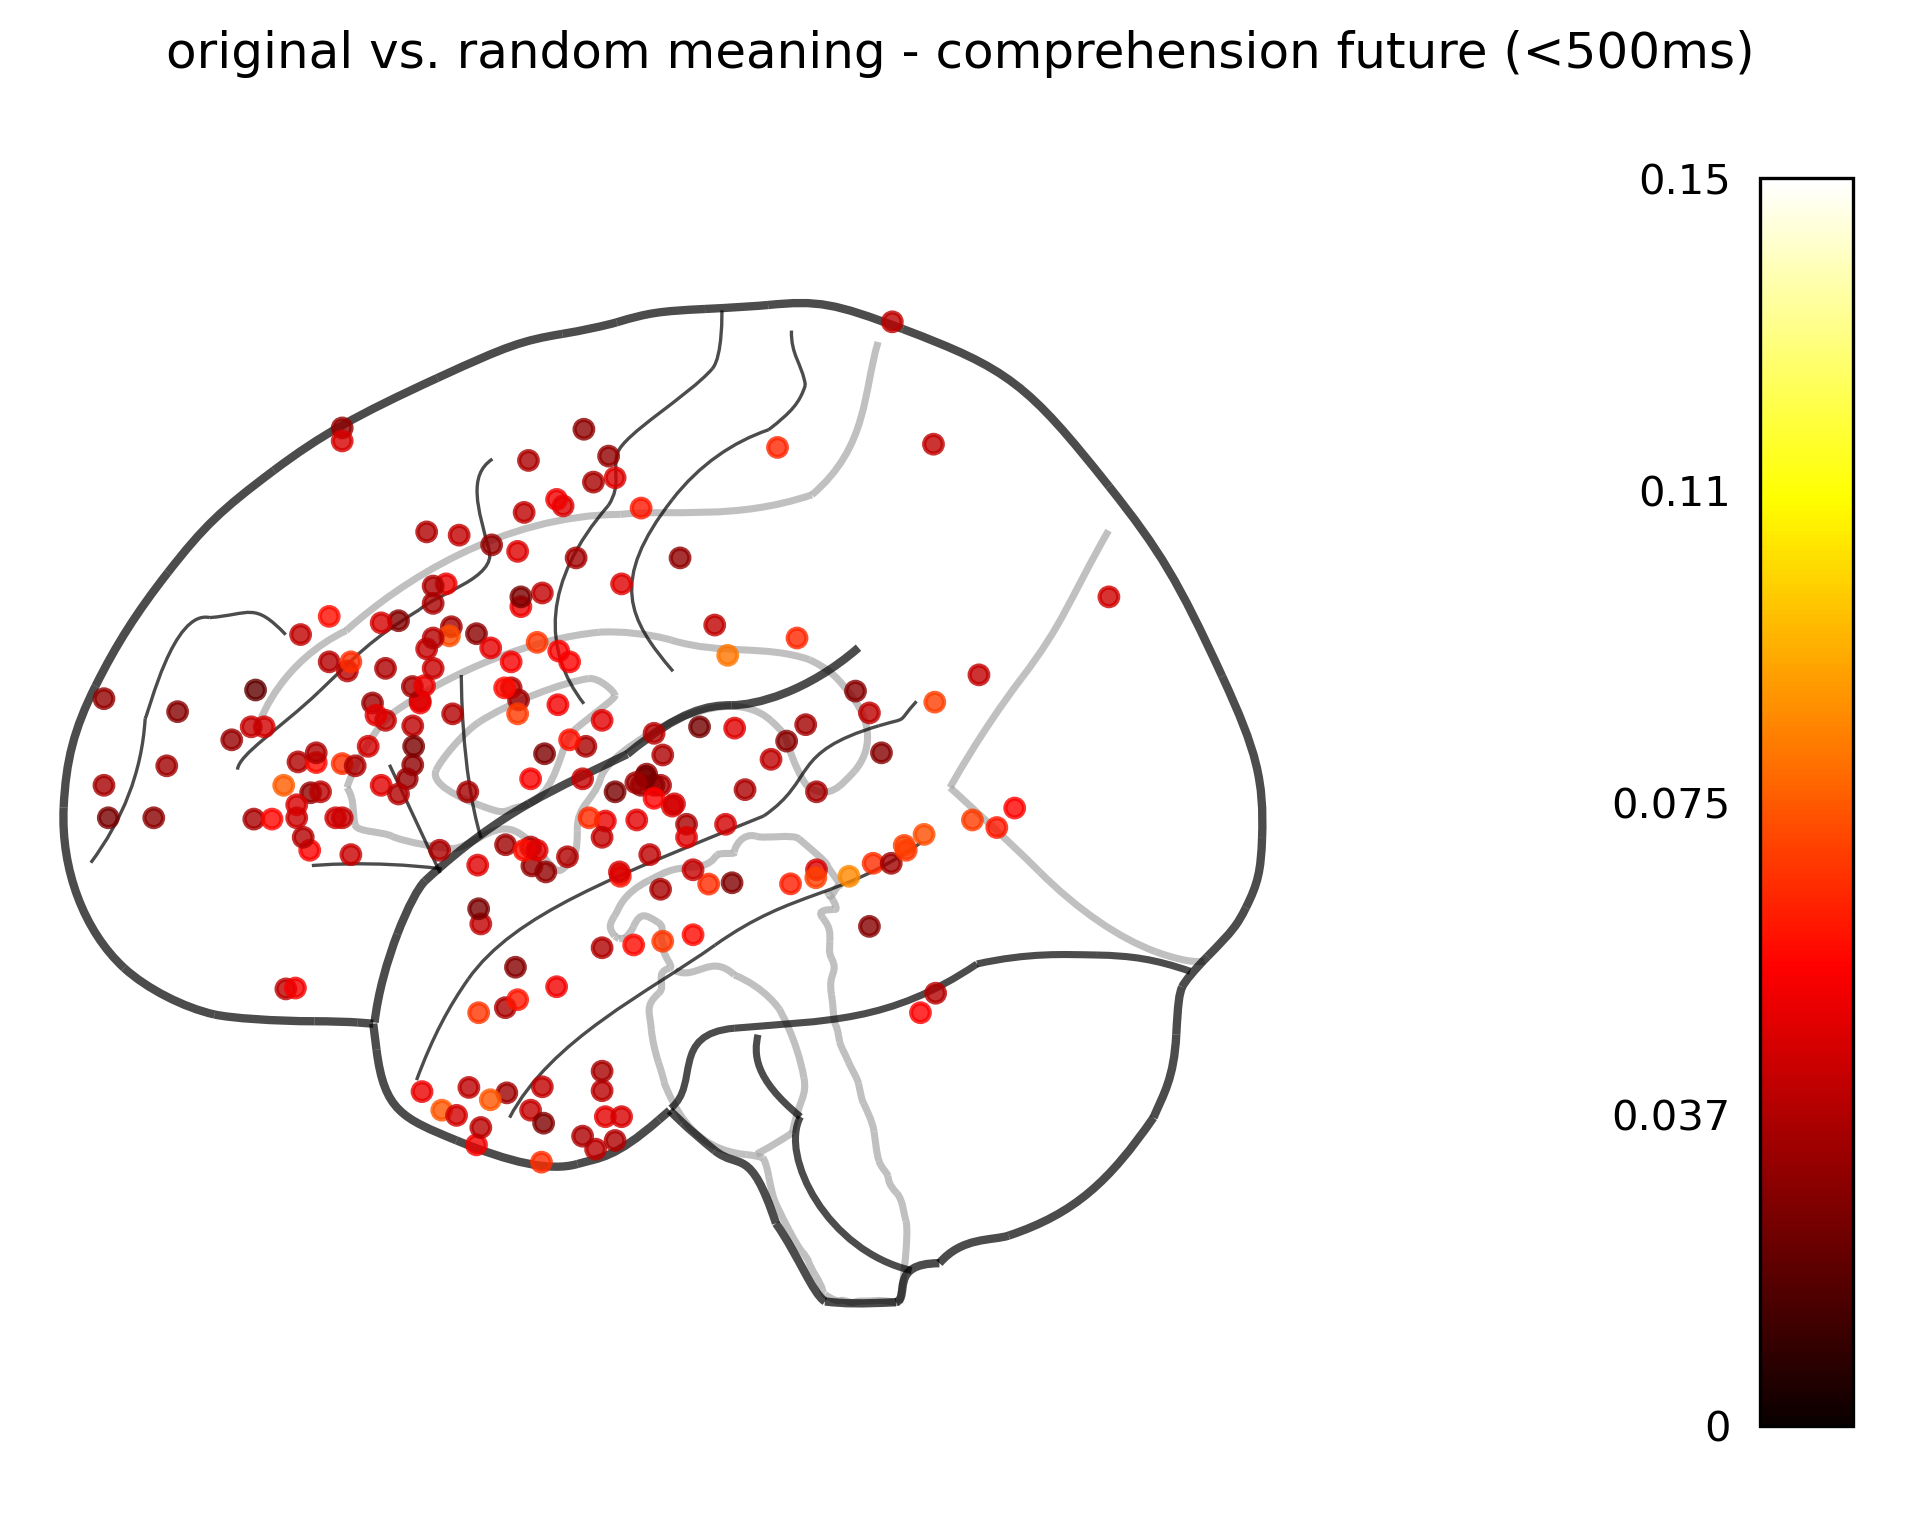

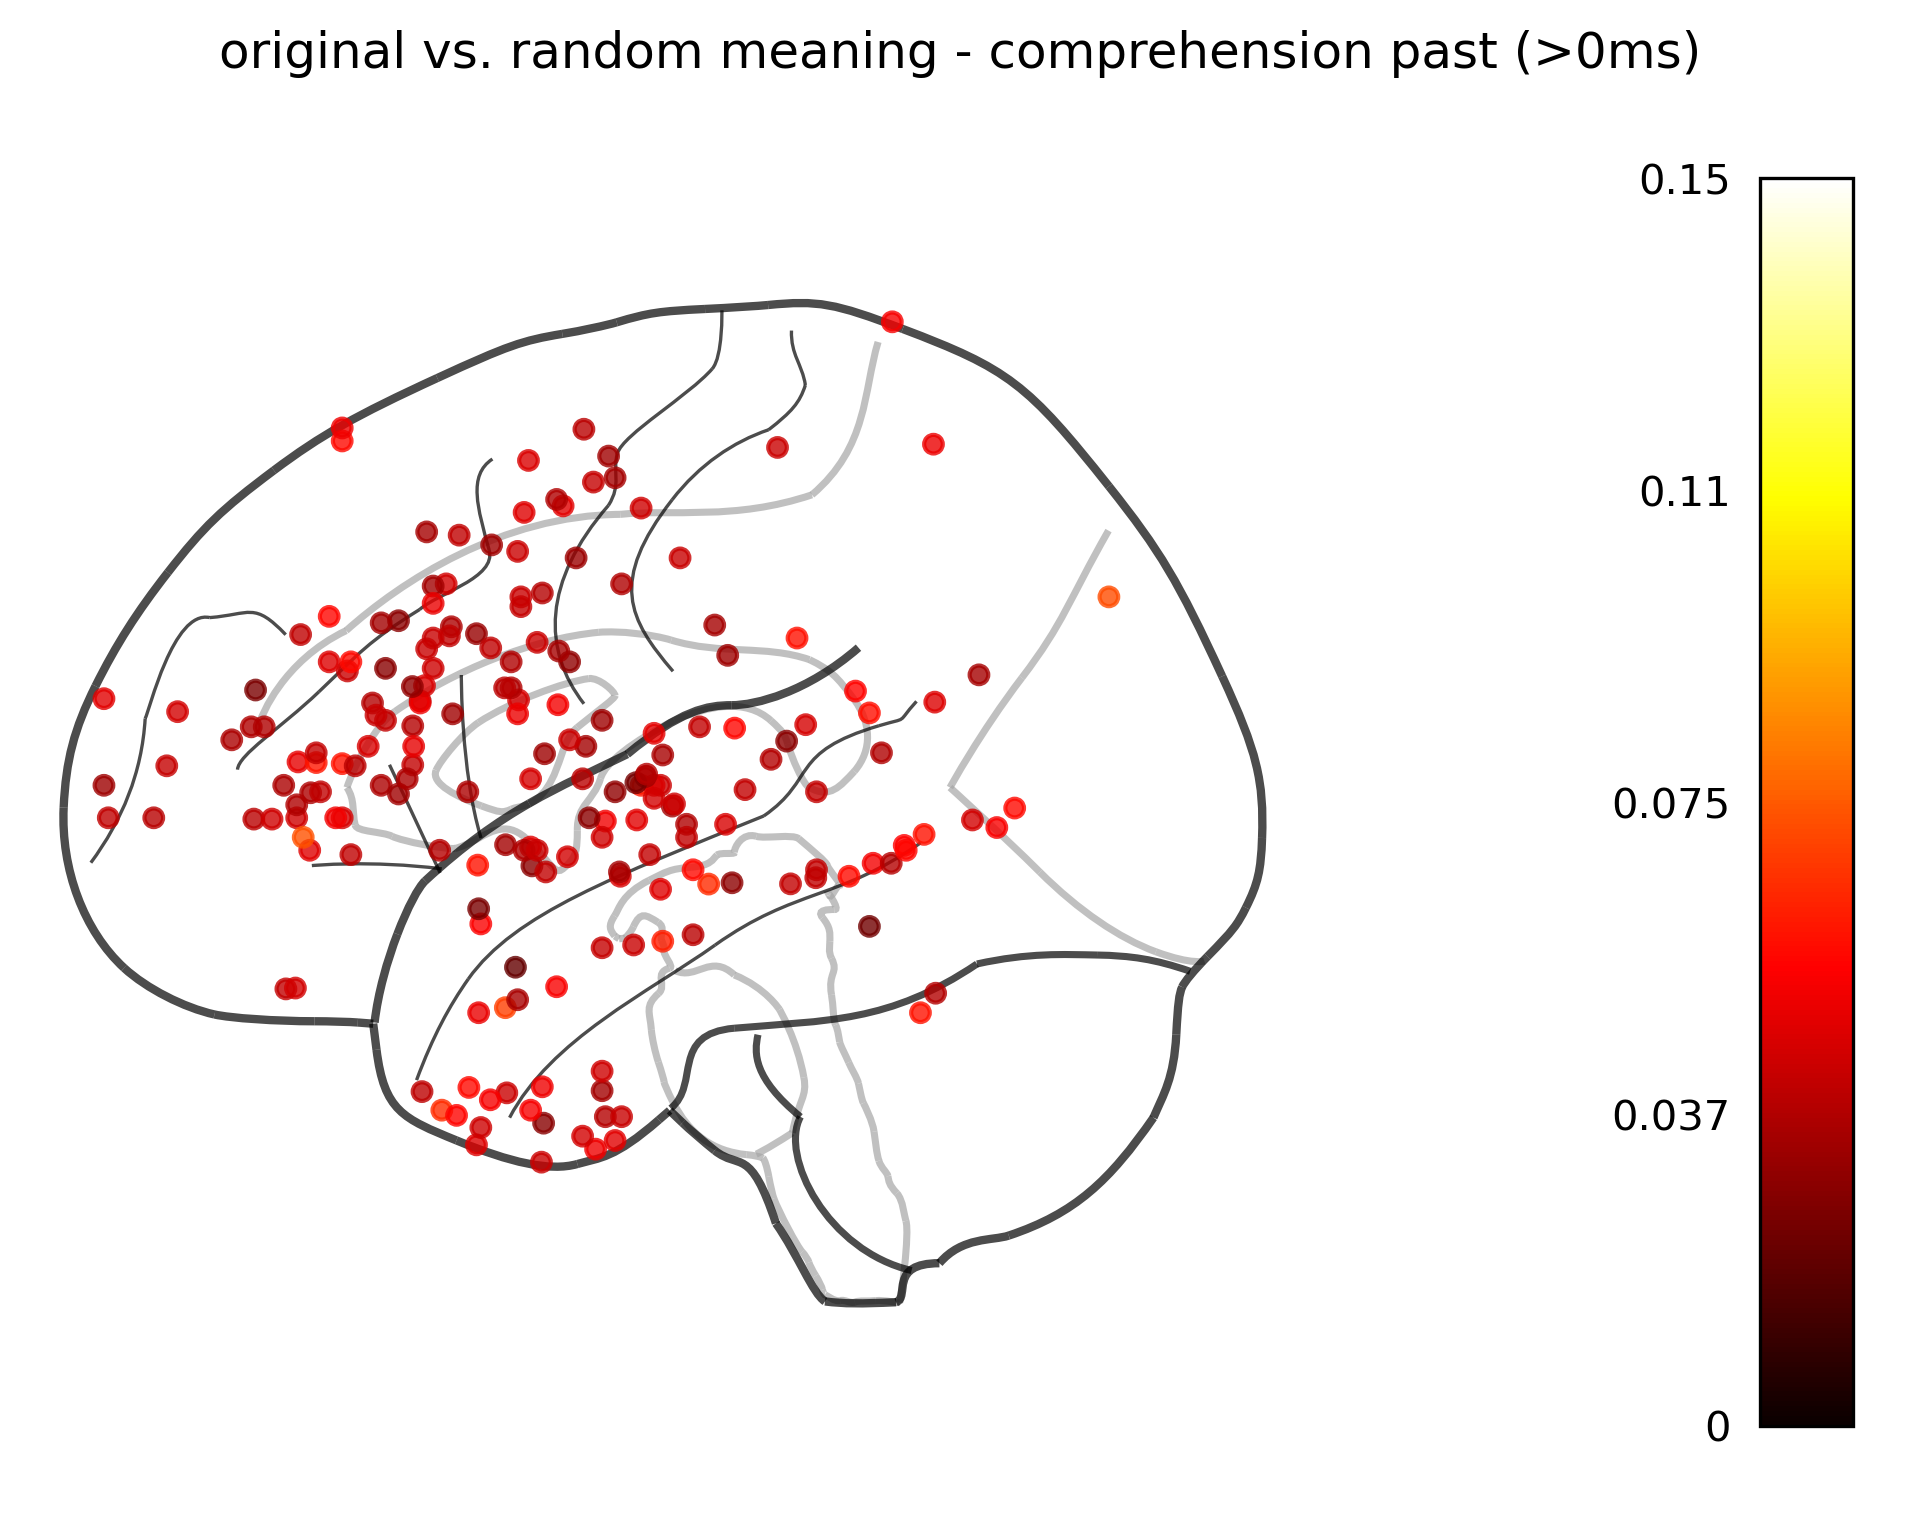

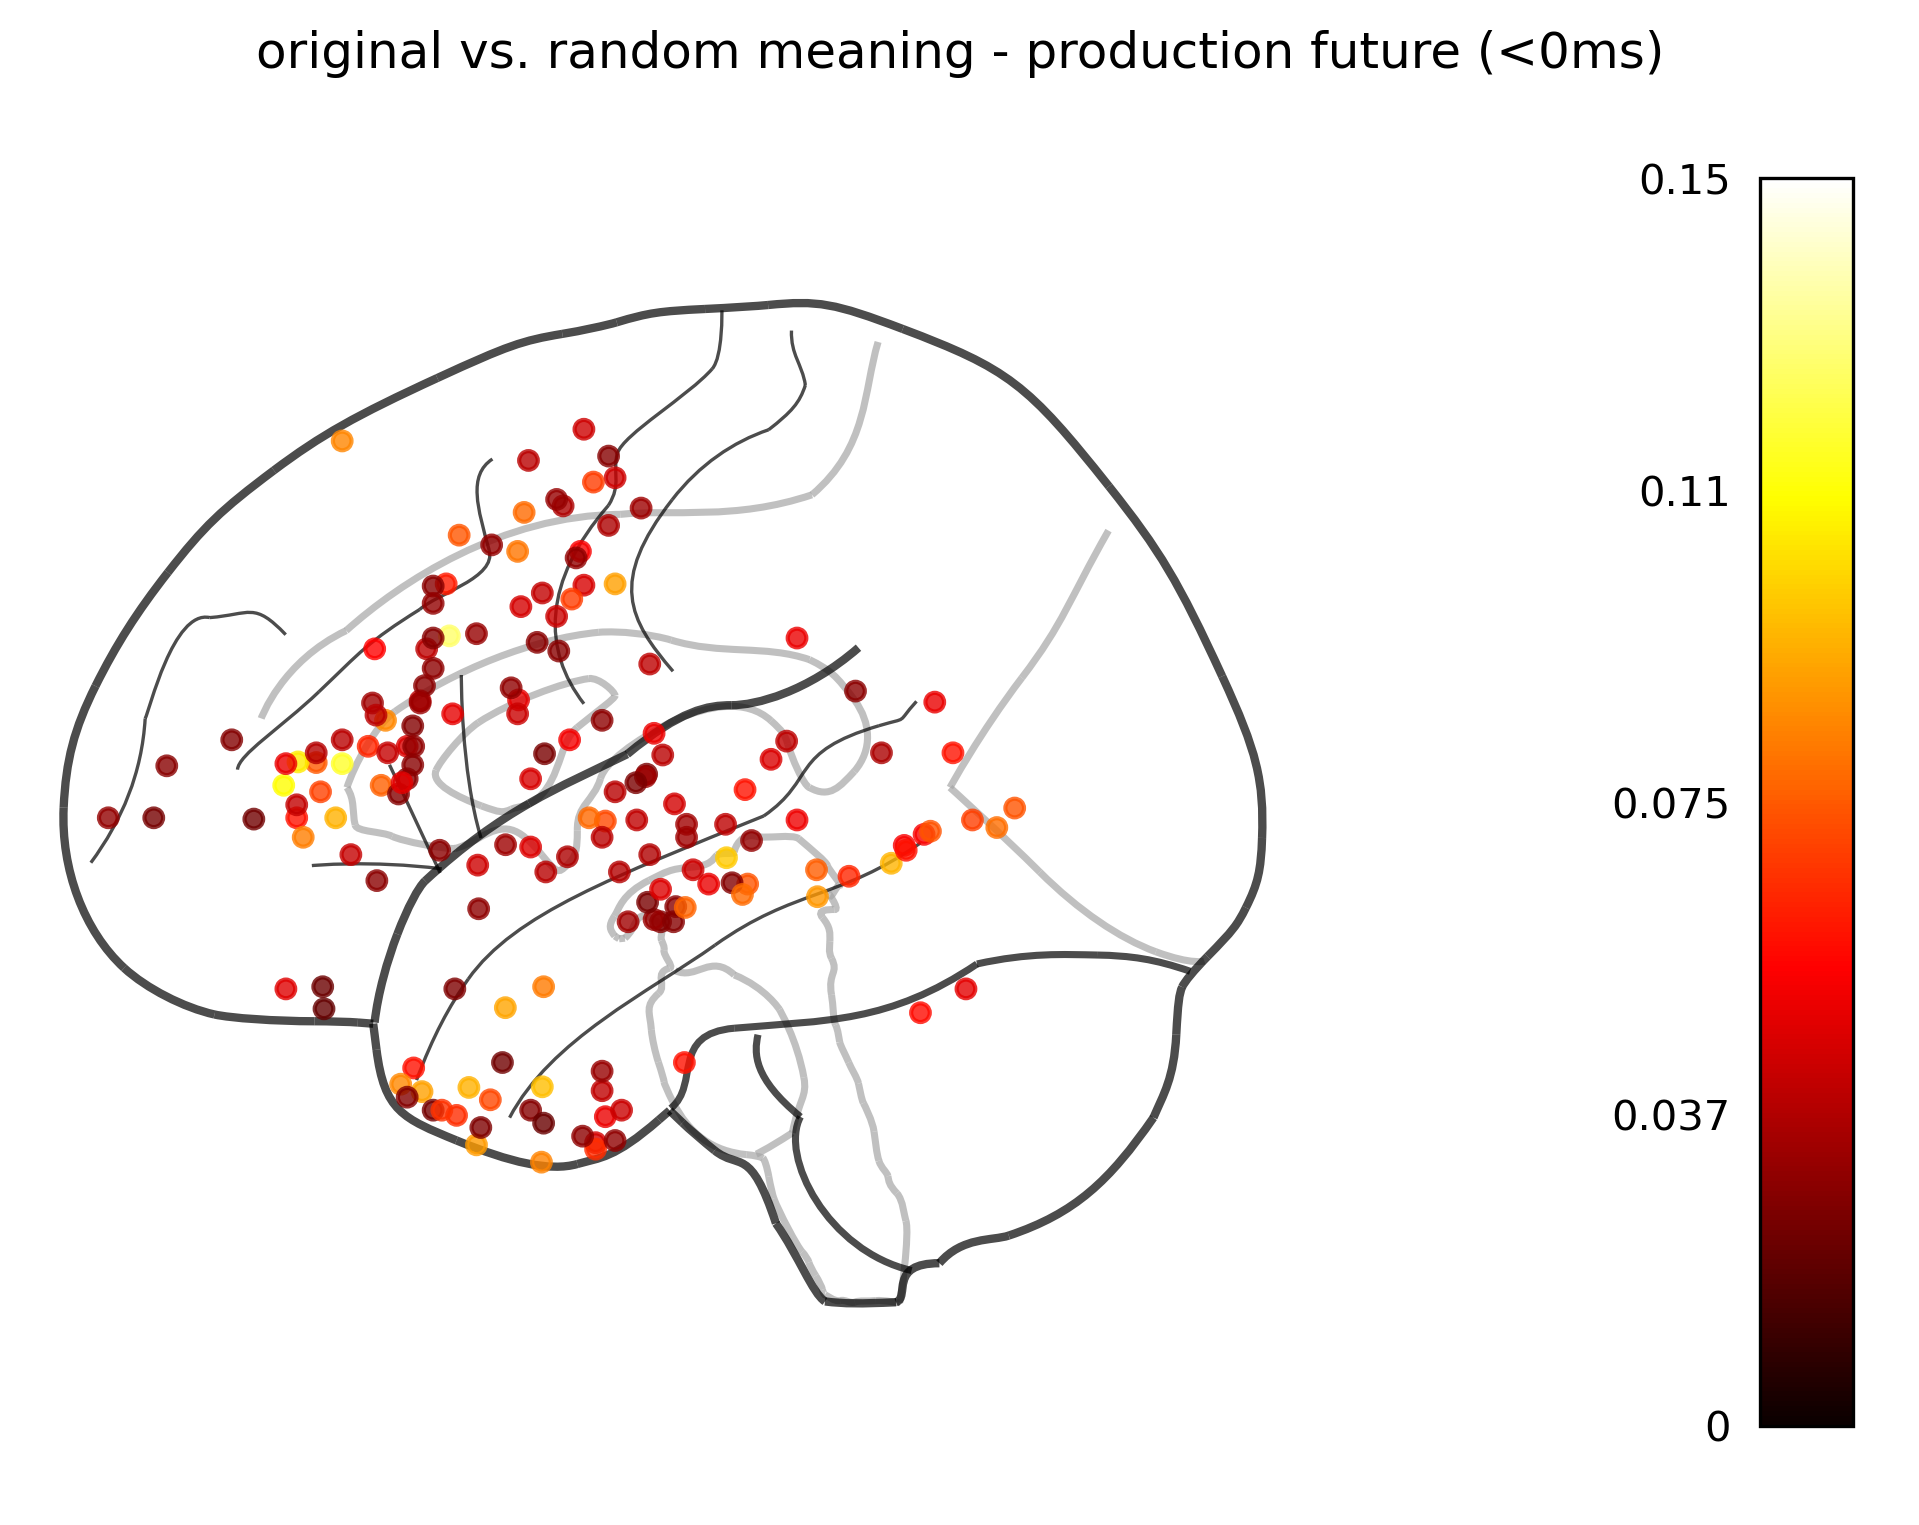

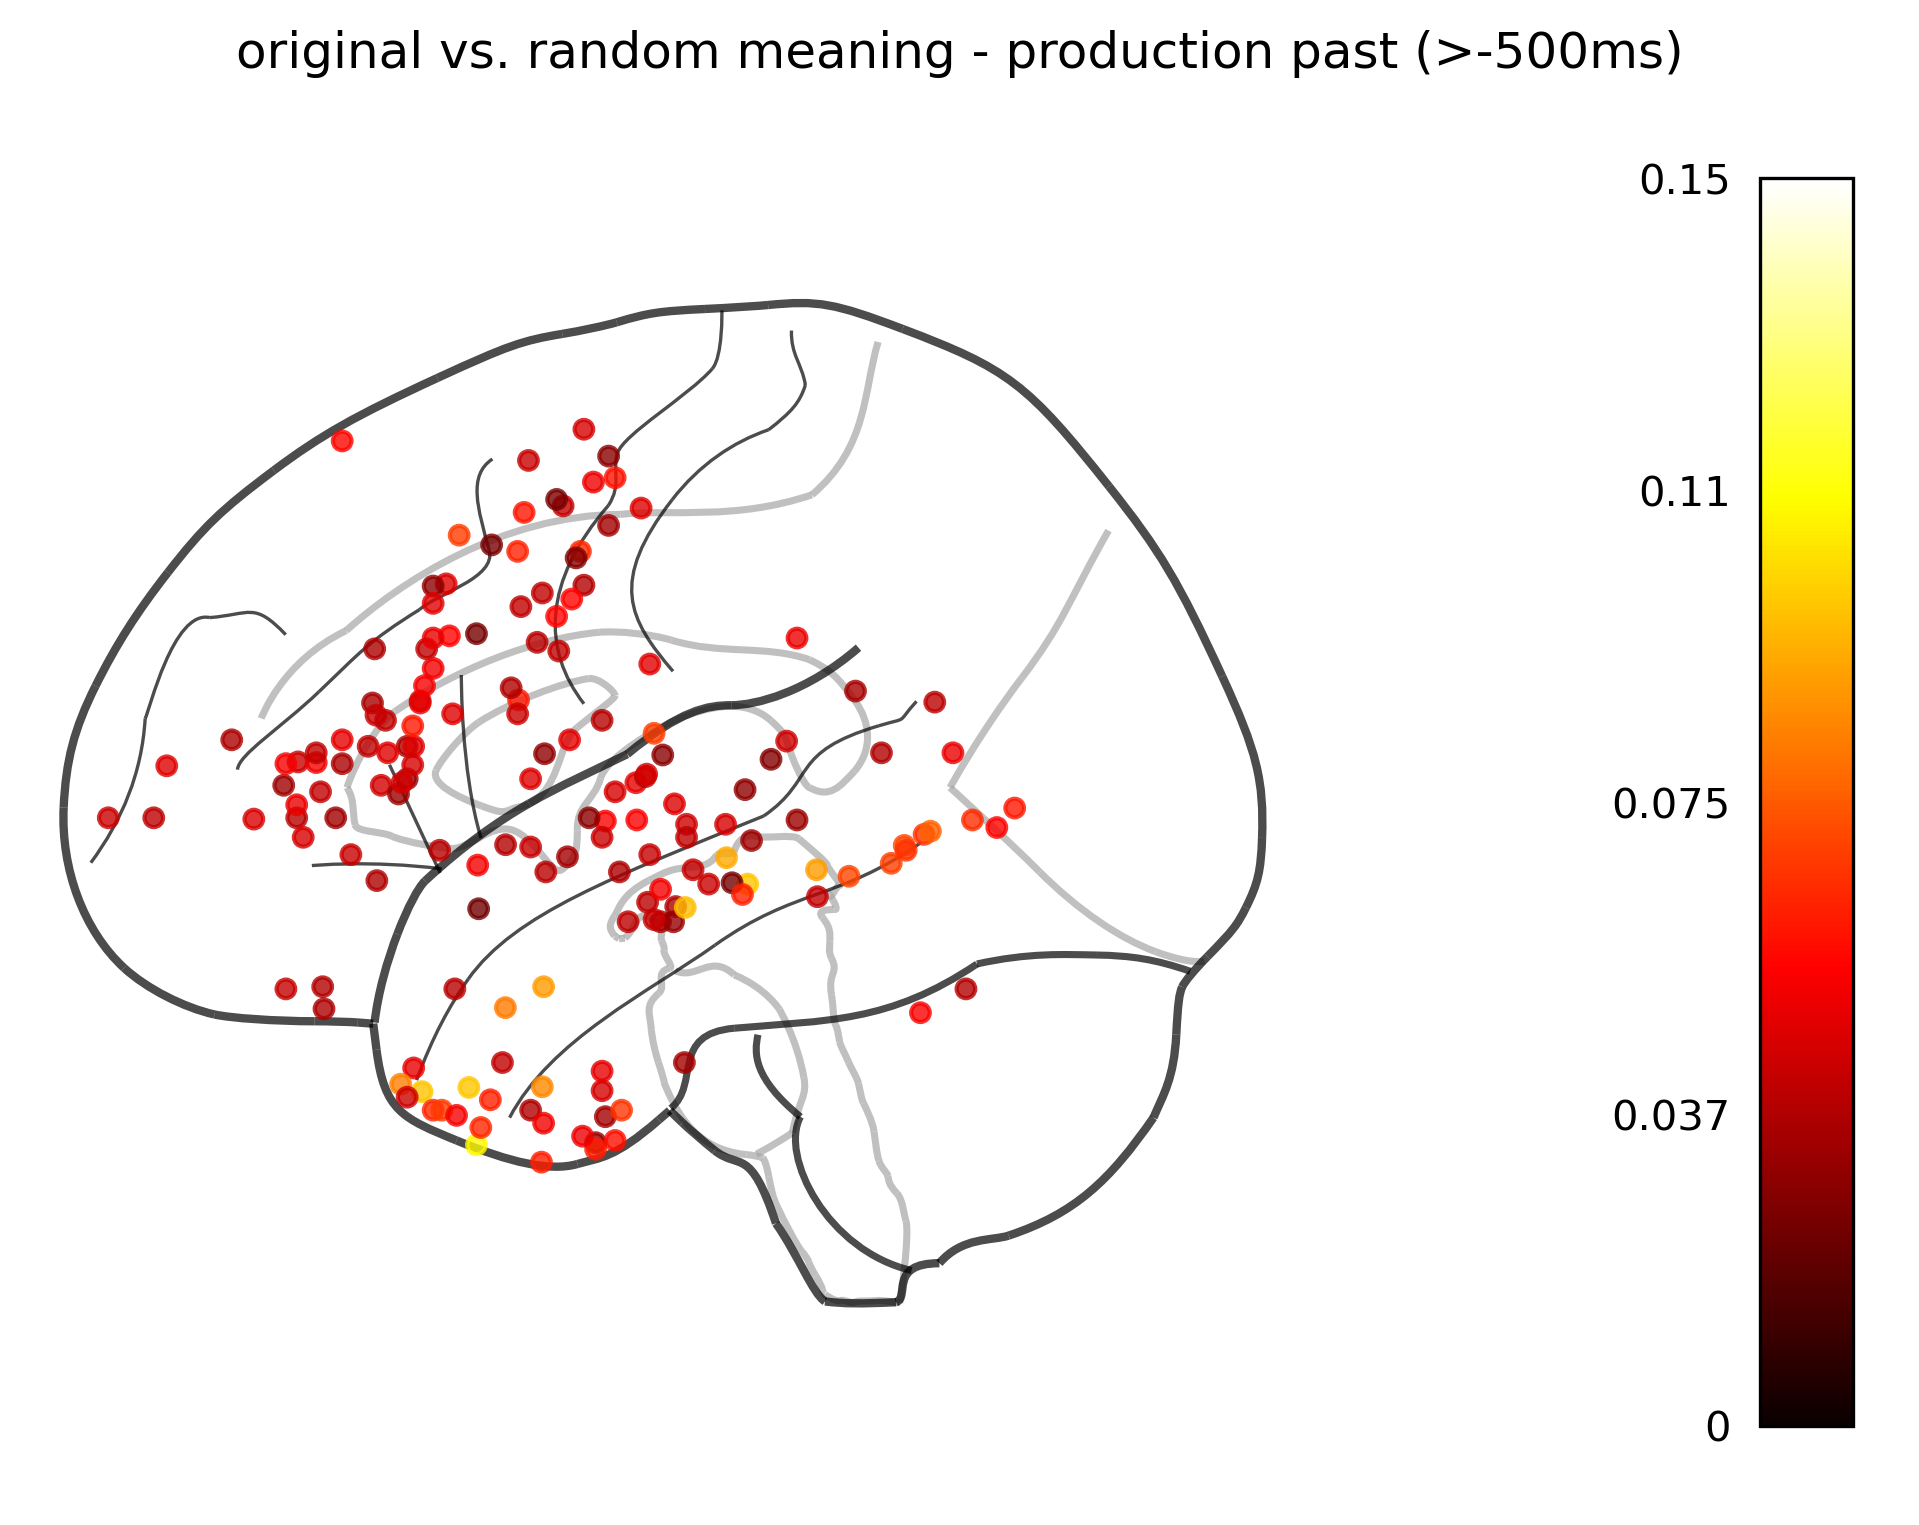

In [56]:
# use label3 and mode to distinguish
diffs_future_comp_df = all_diffs[(all_diffs['mode'] == 'comp') & (all_diffs['label3'] == 'sentence')]
diffs_past_comp_df = all_diffs[(all_diffs['mode'] == 'comp') & (all_diffs['label3'] == 'sentence2')]
diffs_future_prod_df = all_diffs[(all_diffs['mode'] == 'prod') & (all_diffs['label3'] == 'sentence')]
diffs_past_prod_df = all_diffs[(all_diffs['mode'] == 'prod') & (all_diffs['label3'] == 'sentence2')]


# calc diffs between no reph and reph random (same subject + electrode)
# label3 == sentence comprehension get 90th percentile biggest diff for columns <=500
# label3 == sentence2 comprehension get 90th percentile biggest diff for columns >=0
# label3 == sentence production get 90th percentile biggest diff for columns <=0
# label3 == sentence2 production get 90th percentile biggest diff for columns >=-500
cmap = 'hot'
pu.plot_effect_glassbrain(diffs_future_comp_df, cmap=cmap, effect_col='max_diff', vmin=0, vmax=0.15, title='original vs. random meaning - comprehension future (<500ms)')
pu.plot_effect_glassbrain(diffs_past_comp_df,   cmap=cmap, effect_col='max_diff', vmin=0, vmax=0.15, title='original vs. random meaning - comprehension past (>0ms)')
pu.plot_effect_glassbrain(diffs_future_prod_df, cmap=cmap, effect_col='max_diff', vmin=0, vmax=0.15, title='original vs. random meaning - production future (<0ms)')
pu.plot_effect_glassbrain(diffs_past_prod_df,   cmap=cmap, effect_col='max_diff', vmin=0, vmax=0.15, title='original vs. random meaning - production past (>-500ms)')

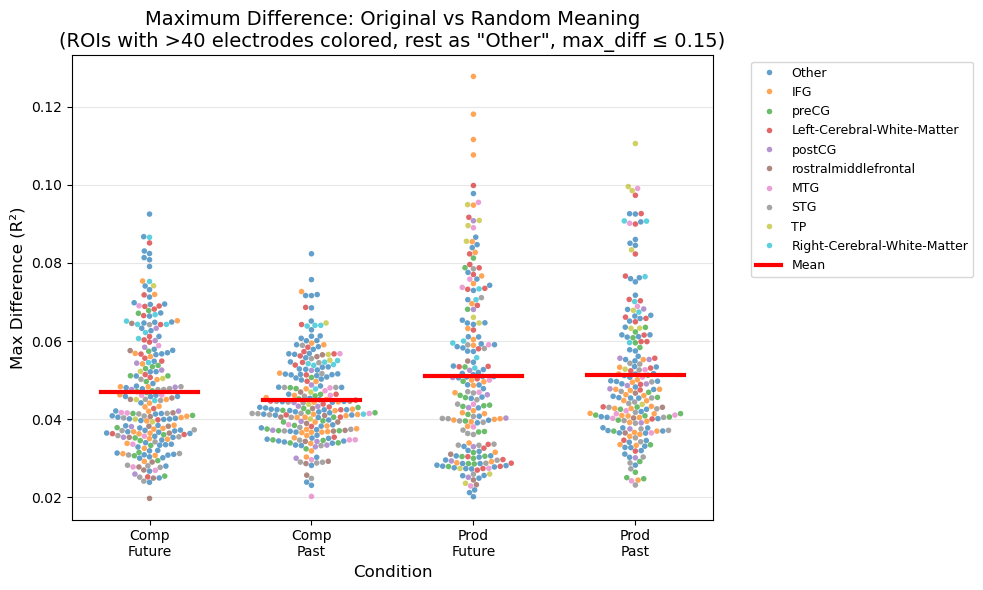


ROI distribution:
Major ROIs (>40 electrodes): ['IFG', 'STG', 'preCG', 'Left-Cerebral-White-Matter', 'MTG', 'postCG', 'rostralmiddlefrontal', 'Right-Cerebral-White-Matter', 'TP']

ROI counts:
  IFG: 120
  STG: 92
  preCG: 88
  Left-Cerebral-White-Matter: 84
  MTG: 42
  postCG: 41
  rostralmiddlefrontal: 38
  Right-Cerebral-White-Matter: 32
  TP: 30
  Other: 224

Mean max differences:
Comp Future: 0.0469
Comp Past: 0.0450
Prod Future: 0.0512
Prod Past: 0.0514


In [66]:
import seaborn as sns

# Prepare data for swarm plot
plot_data = []

for condition, df in [
    ('Comp\nFuture', diffs_future_comp_df),
    ('Comp\nPast', diffs_past_comp_df),
    ('Prod\nFuture', diffs_future_prod_df),
    ('Prod\nPast', diffs_past_prod_df)
]:
    df_copy = df.copy()
    df_copy['condition'] = condition
    plot_data.append(df_copy[['condition', 'max_diff', 'roi']])

plot_df = pd.concat(plot_data, ignore_index=True)

# Remove points > 0.15
plot_df = plot_df[plot_df['max_diff'] <= 0.15]

# Count ROI occurrences and categorize
roi_counts = plot_df['roi'].value_counts()
# (40 electrode across all conditions - meaning 10 electrodes per roi)
major_rois = roi_counts[roi_counts > 28].index.tolist()

# Create new column: use original ROI if count > 15, else 'Other'
plot_df['roi_grouped'] = plot_df['roi'].apply(lambda x: x if x in major_rois else 'Other')

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Create swarm plot with grouped ROI colors
sns.swarmplot(
    data=plot_df,
    x='condition',
    y='max_diff',
    hue='roi_grouped',
    ax=ax,
    size=4,
    alpha=0.7
)

# Calculate and plot means
conditions = ['Comp\nFuture', 'Comp\nPast', 'Prod\nFuture', 'Prod\nPast']
means = [plot_df[plot_df['condition'] == cond]['max_diff'].mean() for cond in conditions]

# Plot mean lines
for i, (cond, mean) in enumerate(zip(conditions, means)):
    ax.plot([i - 0.3, i + 0.3], [mean, mean], 'r-', linewidth=3, zorder=100, label='Mean' if i == 0 else '')

# Formatting
ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Max Difference (R²)', fontsize=12)
ax.set_title('Maximum Difference: Original vs Random Meaning\n(ROIs with >40 electrodes colored, rest as "Other", max_diff ≤ 0.15)', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

# Adjust legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary
print("\nROI distribution:")
print(f"Major ROIs (>40 electrodes): {major_rois}")
print(f"\nROI counts:")
for roi in major_rois:
    print(f"  {roi}: {roi_counts[roi]}")
print(f"  Other: {roi_counts[~roi_counts.index.isin(major_rois)].sum()}")

print("\nMean max differences:")
for cond, mean in zip(conditions, means):
    print(f"{cond.replace(chr(10), ' ')}: {mean:.4f}")

In [64]:
from scipy import stats

# Perform t-tests
print("=" * 60)
print("T-TEST RESULTS")
print("=" * 60)

# Extract data for each condition
comp_future = diffs_future_comp_df['max_diff'].values
comp_past = diffs_past_comp_df['max_diff'].values
prod_future = diffs_future_prod_df['max_diff'].values
prod_past = diffs_past_prod_df['max_diff'].values

# 1. Prod Future vs Comp Future
t_stat, p_val = stats.ttest_ind(prod_future, comp_future)
print(f"\n1. Production Future vs Comprehension Future:")
print(f"   t-statistic: {t_stat:.4f}, p-value: {p_val:.6f}")
print(f"   Mean Prod Future: {prod_future.mean():.4f}, Mean Comp Future: {comp_future.mean():.4f}")

# 2. Prod Past vs Comp Past
t_stat, p_val = stats.ttest_ind(prod_past, comp_past)
print(f"\n2. Production Past vs Comprehension Past:")
print(f"   t-statistic: {t_stat:.4f}, p-value: {p_val:.6f}")
print(f"   Mean Prod Past: {prod_past.mean():.4f}, Mean Comp Past: {comp_past.mean():.4f}")

# 3. Prod Future vs Prod Past
t_stat, p_val = stats.ttest_ind(prod_future, prod_past)
print(f"\n3. Production Future vs Production Past:")
print(f"   t-statistic: {t_stat:.4f}, p-value: {p_val:.6f}")
print(f"   Mean Prod Future: {prod_future.mean():.4f}, Mean Prod Past: {prod_past.mean():.4f}")

# 4. Comp Future vs Comp Past
t_stat, p_val = stats.ttest_ind(comp_future, comp_past)
print(f"\n4. Comprehension Future vs Comprehension Past:")
print(f"   t-statistic: {t_stat:.4f}, p-value: {p_val:.6f}")
print(f"   Mean Comp Future: {comp_future.mean():.4f}, Mean Comp Past: {comp_past.mean():.4f}")

# 5. All Prod (Future + Past) vs All Comp (Future + Past)
all_prod = np.concatenate([prod_future, prod_past])
all_comp = np.concatenate([comp_future, comp_past])
t_stat, p_val = stats.ttest_ind(all_prod, all_comp)
print(f"\n5. All Production vs All Comprehension:")
print(f"   t-statistic: {t_stat:.4f}, p-value: {p_val:.6f}")
print(f"   Mean All Prod: {all_prod.mean():.4f}, Mean All Comp: {all_comp.mean():.4f}")
print(f"   n Prod: {len(all_prod)}, n Comp: {len(all_comp)}")

print("\n" + "=" * 60)

# Sample sizes
print(f"\nSample sizes:")
print(f"  Comp Future: {len(comp_future)}")
print(f"  Comp Past: {len(comp_past)}")
print(f"  Prod Future: {len(prod_future)}")
print(f"  Prod Past: {len(prod_past)}")

T-TEST RESULTS

1. Production Future vs Comprehension Future:
   t-statistic: 2.3693, p-value: 0.018267
   Mean Prod Future: 0.0512, Mean Comp Future: 0.0469

2. Production Past vs Comprehension Past:
   t-statistic: 4.5831, p-value: 0.000006
   Mean Prod Past: 0.0522, Mean Comp Past: 0.0450

3. Production Future vs Production Past:
   t-statistic: -0.4703, p-value: 0.638416
   Mean Prod Future: 0.0512, Mean Prod Past: 0.0522

4. Comprehension Future vs Comprehension Past:
   t-statistic: 1.5637, p-value: 0.118582
   Mean Comp Future: 0.0469, Mean Comp Past: 0.0450

5. All Production vs All Comprehension:
   t-statistic: 4.7958, p-value: 0.000002
   Mean All Prod: 0.0517, Mean All Comp: 0.0460
   n Prod: 392, n Comp: 460


Sample sizes:
  Comp Future: 230
  Comp Past: 230
  Prod Future: 196
  Prod Past: 196
